%pip install -r requirements.txt
%pip install -e git+https://github.com/te-sla/webanno-spacy-converter.git#egg=webanno-spacy-converter

In [1]:
import pandas as pd
from data_loader import load_sense_repo
from config import S_LITERALS

# Reload sense repository to ensure 'literals' column is included now that data_loader defaults were updated
sense_repo_df = load_sense_repo()
print("Loaded sense repository columns:", list(sense_repo_df.columns))
if S_LITERALS not in sense_repo_df.columns:
    print(f"Warning: '{S_LITERALS}' column still missing. Check Excel source or adjust keep_columns parameter.")

Loaded sense repository columns: ['senseID', 'definition', 'Type', 'pos', 'lemma', 'upos', 'literals']


In [2]:
# Combine all annotation chunks into a single sentences list for testing / analysis
from config import ANNOTATION_CHUNKS, DATA_DIR
from webanno_spacy_converter.parsers.tsv_parser_v3 import WebAnnoLEXISParser

all_sentences = []
chunk_meta = []  # (chunk_index, begin, end, file, sentence_count)
CHUNK_PARSERS = []  # keep references if we need parser attributes later
LAYER_NAMES = None

for idx, (begin, end, fname) in enumerate(ANNOTATION_CHUNKS):
    path = DATA_DIR / fname
    chunk_parser = WebAnnoLEXISParser(path)
    sentences = chunk_parser.parse()
    # Capture layer names from the first parser (assumed consistent across chunks)
    if LAYER_NAMES is None:
        try:
            LAYER_NAMES = list(chunk_parser.layer_names)
        except Exception:
            LAYER_NAMES = []
    all_sentences.extend(sentences)
    CHUNK_PARSERS.append(chunk_parser)
    chunk_meta.append((idx, begin, end, fname, len(sentences)))

print("Loaded chunks (index, begin, end, file, #sentences):")
for meta in chunk_meta:
    print(meta)

print(f"Total combined sentences: {len(all_sentences)}")
print(f"Captured {len(LAYER_NAMES) if LAYER_NAMES else 0} layer names from first chunk.")

# For backward compatibility with existing notebook code that expects `senteces`
senteces = all_sentences

# Optional: quick test mode to downsample for rapid iteration
TEST_LIMIT = None  # set e.g. 50 to only keep first 50 sentences
if TEST_LIMIT is not None:
    senteces = senteces[:TEST_LIMIT]
    print(f"Test mode active -> using first {len(senteces)} sentences only")


Loaded chunks (index, begin, end, file, #sentences):
(0, 1, 500, 'sr-elexis-WSD_0001_0500.tsv', 500)
(1, 501, 1000, 'sr-elexis-WSD_0501_1000.tsv', 500)
(2, 1001, 1500, 'sr-elexis-WSD_1001_1500.tsv', 500)
(3, 1501, 2000, 'sr-elexis-WSD_1501_2000.tsv', 500)
(4, 2001, 2024, 'sr-elexis-WSD_2001_2024.tsv', 24)
Total combined sentences: 2024
Captured 14 layer names from first chunk.


In [3]:
# for sentence in senteces:
#     print(sentence)
#     for mwe in sentence.mwes: # type: ignore
#         print(mwe)
#     print("")
#     print(sentence.text)
#     for token in sentence.tokens:
#         print(token)


In [4]:
# Display collected layer names (from the first chunk parser)
LAYER_NAMES

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

In [5]:
sent = senteces[0]

In [6]:
for sentence in senteces:
    print(sentence.text)
    for mwe in sentence.mwes: # type: ignore
        print(mwe)
    print("")

U petoj sezoni program je održan u skladu sa novim konceptom: jedan mladi fudbaler iz svake zemlje izabran je kao njen predstavnik.
MultiWordExpression(lemma='u skladu sa', token_count=3, token_indices=[6, 7, 8], type='AdpID', group_id='1')

Krup pogađa oko 15 % dece i obično se javlja između 6 meseci i 5–6 godina.
MultiWordExpression(lemma='javljati se', token_count=2, token_indices=[8, 9], type='IRV', group_id='1')

Poznati fudbaleri, među kojima i srpski defanzivac Branislav Ivanović i holandski napadač Dirk Kojt, učestvovali su u raznim događajima širom sveta.

Više od 7000 ljudi otišlo je na premijeru filma u Damasku.

Kulminacija je bila ceremonija dodele Kupa devet vrednosti (Nine Values Cup), koji je osvojio fudbalski klub Barselona.

U junu 2014, kao vođa pokreta, posetio je deveti međunarodni omladinski fudbalski turnir organizovan u znak sećanja na Jurija Andrejeviča Morozova.
MultiWordExpression(lemma='u znak', token_count=2, token_indices=[16, 17], type='AdpID', group_id='

In [7]:
for sentece in senteces:
    for mwe in sentece.mwes: # type: ignore
        if mwe.lemma == "*":
            print(f"mwe lemma is * for {sentece.text} with mwe {mwe}")

In [8]:
sense_repo_df

,senseID,definition,Type,pos,lemma,upos,literals
0,BILI-00000025,Otac jednog supružnika prema drugom supružniku.,S,N,prijatelj,NOUN,prijatelj
1,BILI-00000027,Koji se odnosi na policiju.,S,A,policijski,ADJ,policijski
2,BILI-00000033,Dobrovoljni član organizacije koja obuhvata de...,S,N,pionir,NOUN,pionir; Titov pionir
3,BILI-00000104,Majka jednog od supružnika prema roditeljima d...,S,N,prijateljica,NOUN,prija; prijateljica
4,BILI-00000142,Svečano gošćenje i zadušnice na uspomenu umrlo...,S,N,pomen,NOUN,pomen
...,...,...,...,...,...,...,...
13278,ENG30-00748515-n,čin konzumiranja alkoholnih pića u prekomernim...,NaN,N,opijanje,NOUN,opijanje; piće; pijanstvo; pijenje; šljokanje
13279,ENG30-00748515-n,čin konzumiranja alkoholnih pića u prekomernim...,NaN,N,pijanstvo,NOUN,opijanje; piće; pijanstvo; pijenje; šljokanje
13280,ENG30-00748515-n,čin konzumiranja alkoholnih pića u prekomernim...,NaN,N,pijenje,NOUN,opijanje; piće; pijanstvo; pijenje; šljokanje
13281,ENG30-02158846-n,Upadljivo označen ili oblikovan zadnji deo.,NaN,N,rep,NOUN,NaN


In [9]:
# Diagnostics: inspect available columns in the sense repository
print("Sense repository columns:", list(sense_repo_df.columns))
missing = []
for required in ["lemma", "definition", "literals", "Type", "senseID"]:
    if required not in sense_repo_df.columns:
        missing.append(required)
if missing:
    print("Missing expected columns:", missing)
else:
    print("All expected columns present.")

Sense repository columns: ['senseID', 'definition', 'Type', 'pos', 'lemma', 'upos', 'literals']
All expected columns present.


In [10]:
from config import S_LEMMA, S_TYPE

# Iterate over each sentence and its multi-word expressions (MWEs),
# filtering the sense repository ONLY by lemma (type filtering removed as too strict).
mwe_senses = []
for sentece in senteces:
    for mwe in sentece.mwes: # type: ignore
        lemma = mwe.lemma
        # Skip wildcard or placeholder entries
        if lemma == "*":
            continue

        print(f"Looking up senses for lemma '{lemma}' (MWE matching by lemma only):")
        # Retain original extracted type for metadata, but not used in filtering
        type = (mwe.type).split("[")[0].strip()
        # Filter rows where the canonical lemma column matches exactly (type removed)
        filtered_rows = sense_repo_df[(sense_repo_df[S_LEMMA] == lemma)]

        # Display the matching rows and how many we found
        print(filtered_rows)
        print(f"Found {len(filtered_rows)} sense(s).\n")

        # Record the lemma, its full DataFrame slice, and the count
        mwe_sense = {
            "lemma":               lemma,
            "type":                mwe.type,
            "senses":              filtered_rows,
            "Number of senses":    len(filtered_rows),
            "sentence":           sentece.text,
        }
        mwe_senses.append(mwe_sense)




Looking up senses for lemma 'u skladu sa' (MWE matching by lemma only):
        senseID                                      definition   Type   pos  \
12974  LLM-0288  U harmoniji sa; prema nečemu; saglasno nečemu.  AdpID  PREP   

             lemma upos literals  
12974  u skladu sa  ADP      NaN  
Found 1 sense(s).

Looking up senses for lemma 'javljati se' (MWE matching by lemma only):
        senseID                          definition Type pos        lemma  \
890  CVMWE-0161  pojaviti se, nastati (i o bolesti)  IRV   V  javljati se   

     upos               literals  
890  VERB  javiti se;javljati se  
Found 1 sense(s).

Looking up senses for lemma 'u znak' (MWE matching by lemma only):
        senseID                               definition   Type   pos   lemma  \
12985  LLM-0301  Kao simbol nečega; u cilju pokazivanja.  AdpID  PREP  u znak   

      upos literals  
12985  ADP      NaN  
Found 1 sense(s).

Looking up senses for lemma 'fudbalski tim' (MWE matching by lemma on

In [11]:
more_than_one_sense = []
no_sense = []
for mwe_sense in mwe_senses:
    if mwe_sense["Number of senses"] > 1:
        print(f"mwe {mwe_sense['lemma']} has more than one sense")
        rows = mwe_sense["senses"]
        for index, row in rows.iterrows():
            print(f"mwe {mwe_sense['lemma']} has sense {row['senseID']} with definition {row['definition']}")
        more_than_one_sense.append(mwe_sense["lemma"])
    
    if mwe_sense["Number of senses"] == 0:
        print(f"mwe {mwe_sense['lemma']} has no sense")
        print(mwe_sense["senses"])
        no_sense.append(mwe_sense["lemma"])

mwe sastajati se has more than one sense
mwe sastajati se has sense CVMWE-0393 with definition skupiti se, sabrati na ugovorenom mestu radi održavanja nekog sastanka
mwe sastajati se has sense ENG30-01079480-v with definition sa kakvim se protivnikom u sportu, igri ili bici nadmetati
mwe sastajati se has sense ENG30-02023107-v with definition sresti se
mwe sastajati se has sense ENG30-02486232-v with definition izlaziti redovno; imati stalan odnos sa nekim
mwe baviti se has more than one sense
mwe baviti se has sense CVMWE-0011 with definition zanimati se nečim, raditi, poslovati nešto
mwe baviti se has sense CVMWE-0012 with definition obrađivati nešto kao temu knjige, filma i sl.
mwe baviti se has sense CVMWE-0013 with definition proučavati nešto, imati nešto za predmet proučavanja
mwe baviti se has sense ENG30-00651145-v with definition posmatrati ili razmotriti na poseban način
mwe baviti se has sense ENG30-01033527-v with definition Baviti se nečim verbalno ili u nekom obliku umetn

In [12]:
len(more_than_one_sense), len(no_sense)

(284, 0)

In [13]:
#remove duplicates from more_than_one_sense and no_sense
more_than_one_sense = list(set(more_than_one_sense))
no_sense = list(set(no_sense))

In [14]:
print(f"mwe with more than one sense: {more_than_one_sense}")
print(f"mwe with no sense: {no_sense}")

mwe with more than one sense: ['sastojati se', 'životni ciklus', 'vrteti se', 'zainteresovati se', 'razvijati se', 'mentalni poremećaj', 'vinova loza', 'aqua regia', 'baviti se', 'remek-delo', 'rastvarati se', 'starosna grupa', 'pogoršavati se', 'svađati se', 'stabilni izotop', 'prenositi se', 'videti se', 'pridružiti se', 'suprotstavljati se', 'javiti se', 'nastaniti se', 'takmičiti se', 'mučiti se', 'rodno mesto', 'širiti se', 'odnositi se', 'komunikacioni sistem', 'hraniti se', 'oženiti se', 'nitro-jedinjenje', 'popraviti se', 'ticati se', 'udati se', 'sastati se', 'pokret otpora', 'povećati se', 'tvrdi disk', 'zaraziti se', 'radio-talasi', 'suprotstaviti se', 'oslobađati se', 'bojni brod', 'puniti se', 'pojavljivati se', 'dopasti se', 'red veličine', 'dati ostavku', 'razboleti se', 'uzdati se', 'u potpunosti', 'izgubiti se', 'promeniti se', 'plašiti se', 'pokazati se', 'u trenutku', 'stabilizovati se', 'dnevni list', 'smanjivati se', 'razvesti se', 'poslednja reč', 'sastajati se', 

In [15]:
for mwe_sense in mwe_senses:
    if mwe_sense["Number of senses"] == 0:
        print(f"mwe {mwe_sense['lemma']} has no sense")
        print(mwe_sense["sentence"])



In [16]:
mwe_for_save = []

from config import S_ID, S_DEFINITION, S_LITERALS, S_TYPE
missing_literals_warned = False
missing_type_warned = False

for mwe_sense in mwe_senses:
    lemma = mwe_sense["lemma"]
    type = mwe_sense["type"]
    number_of_senses = mwe_sense["Number of senses"]
    all_senses = None
    if number_of_senses > 0:
        all_senses = []
        for index, row in mwe_sense["senses"].iterrows():
            literals_val = row.get(S_LITERALS, None)
            if literals_val is None and not missing_literals_warned:
                print(f"Warning: column '{S_LITERALS}' not found in sense repository rows (showing once). Available: {list(row.index)}")
                missing_literals_warned = True
            type_val = row.get(S_TYPE, None)
            if type_val is None and not missing_type_warned:
                print(f"Warning: column '{S_TYPE}' not found (showing once). Available: {list(row.index)}")
                missing_type_warned = True
            all_senses.append((row.get(S_ID), row.get(S_DEFINITION), literals_val, type_val))
    mwe_for_save.append({
        "lemma": lemma,
        "type": type,
        "number_of_senses": number_of_senses,
        "all_senses": all_senses,
        "sentence": mwe_sense["sentence"],
    })

import json
with open("mwe_for_save.json", "w", encoding="utf-8") as f:
    json.dump(mwe_for_save, f, indent=4, ensure_ascii=False)
    


In [17]:
# save the mwe with more one sense to a file, UTF-8 encoding
with open("mwe_with_more_than_one_sense.txt", "w", encoding="utf-8") as f:
    for mwe in more_than_one_sense:
        f.write(mwe + "\n")

In [18]:
with open("mwe_with_no_sense.txt", "w", encoding="utf-8") as f:
    for mwe in no_sense:
        f.write(mwe + "\n")

In [19]:
mwe_senses_df = pd.DataFrame(mwe_senses)

mwe_senses_df["Number of senses"].value_counts()

Number of senses
1    1103
2     163
4      50
3      43
5      15
8       8
6       5
Name: count, dtype: int64

In [20]:
for sentece in senteces:
    for mwe in sentece.mwes:
        if mwe.lemma == "LVC.full":
            print(f"{sentece.text} with mwe {mwe}")

In [21]:
for sentece in senteces:
    for mwe in sentece.mwes:
        if mwe.lemma == "1":
            print(f"mwe lemma is 1 for {sentece.text} with mwe {mwe}")

In [22]:
len(no_sense)

0

In [23]:
no_sense

[]

In [24]:
len(more_than_one_sense)

138

In [25]:
sent = senteces[0]
token = sent.tokens[0]
token

AnnotationToken(sentence_index=1, token_index=1, text='U', start=0, end=1, layers={'PosValue': 'PREP', 'coarseValue': 'ADP', 'value_4': 'u'})

In [26]:
token.layers.keys()

dict_keys(['PosValue', 'coarseValue', 'value_4'])

In [27]:
from config import L_MWE_ID

def token_is_not_in_mwe(token) -> bool:
    """
    Check whether a token is NOT part of a multi-word expression (MWE).

    A token belonging to an MWE will have an MWE ID in its layers under the
    key given by L_MWE_ID. If that ID is one of the placeholder values
    ('*', '', '_', '0') or the layer is missing entirely, we consider the
    token as not in an MWE.

    Args:
        token: An object (e.g., AnnotationToken) with a `.layers` dict
               mapping field names to their annotation values.

    Returns:
        True if the token is not part of a real MWE, False if it has a valid
        MWE ID.
    """
    # Fetch the MWE ID (or empty string if the layer is absent)
    mwe_id = token.layers.get(L_MWE_ID, "")

    # IDs that indicate "no real MWE membership"
    invalid_ids = {"*", "", "_", "0"}

    return mwe_id in invalid_ids


In [28]:
token_is_not_in_mwe(token)

True

In [29]:
for token in sent.tokens:
    if token_is_not_in_mwe(token):
        print(f"token {token.text} is not in mwe")
    else:
        print(f"token {token.text} is in mwe")

token U is not in mwe
token petoj is not in mwe
token sezoni is not in mwe
token program is not in mwe
token je is not in mwe
token održan is not in mwe
token u is in mwe
token skladu is in mwe
token sa is in mwe
token novim is not in mwe
token konceptom is not in mwe
token : is not in mwe
token jedan is not in mwe
token mladi is not in mwe
token fudbaler is not in mwe
token iz is not in mwe
token svake is not in mwe
token zemlje is not in mwe
token izabran is not in mwe
token je is not in mwe
token kao is not in mwe
token njen is not in mwe
token predstavnik is not in mwe
token . is not in mwe


In [30]:
from config import L_NAMED_ENT

def token_is_not_in_ne(token) -> bool:
    """
    Determine whether a token is NOT a named entity.

    A named-entity token will have its entity label in the layer keyed by
    L_NAMED_ENT. If that key is missing or its value is one of the placeholder
    markers ('*', '', '_', '0'), we treat the token as not belonging to any
    named entity.

    Args:
        token: An object (e.g., AnnotationToken) with a `.layers` dict
               mapping field names to annotation values.

    Returns:
        True if the token is not part of a named entity, False otherwise.
    """
    # Retrieve the named-entity value (defaults to empty string if absent)
    ne_value = token.layers.get(L_NAMED_ENT, "")

    # Values that indicate "no named-entity membership"
    invalid_values = {"*", "", "_", "0"}

    return ne_value in invalid_values


In [31]:
for token in sent.tokens:
    if token_is_not_in_ne(token):
        print(f"token {token.text} is not in ne")
    else:
        print(f"token {token.text} is in ne")

token U is not in ne
token petoj is not in ne
token sezoni is not in ne
token program is not in ne
token je is not in ne
token održan is not in ne
token u is not in ne
token skladu is not in ne
token sa is not in ne
token novim is not in ne
token konceptom is not in ne
token : is not in ne
token jedan is not in ne
token mladi is not in ne
token fudbaler is in ne
token iz is not in ne
token svake is not in ne
token zemlje is not in ne
token izabran is not in ne
token je is not in ne
token kao is not in ne
token njen is not in ne
token predstavnik is not in ne
token . is not in ne


In [32]:
def token_is_simple_word(token) -> bool:
    """
    Check whether a token is a simple, standalone word (i.e., neither part of a
    multi-word expression nor a named entity).

    This function returns True only if:
    - token_is_not_in_mwe(token) is True, AND
    - token_is_not_in_ne(token) is True.

    Args:
        token: An object (e.g., AnnotationToken) with a `.layers` dict of annotations.

    Returns:
        bool: True if the token is a simple word, False otherwise.
    """
    # A token is 'simple' if it’s not in any MWE and not in any named entity
    return token_is_not_in_mwe(token) and token_is_not_in_ne(token)

    

In [33]:
for token in sent.tokens:
    if token_is_simple_word(token):
        print(f"token {token.text} is a simple word")
    else:
        print(f"token {token.text} is not a simple word")

token U is a simple word
token petoj is a simple word
token sezoni is a simple word
token program is a simple word
token je is a simple word
token održan is a simple word
token u is not a simple word
token skladu is not a simple word
token sa is not a simple word
token novim is a simple word
token konceptom is a simple word
token : is a simple word
token jedan is a simple word
token mladi is a simple word
token fudbaler is not a simple word
token iz is a simple word
token svake is a simple word
token zemlje is a simple word
token izabran is a simple word
token je is a simple word
token kao is a simple word
token njen is a simple word
token predstavnik is a simple word
token . is a simple word


In [34]:
# now to exmaine in sense repo it onlmaes to by POS tahte exist there

pos = sense_repo_df["pos"].unique()
upos = sense_repo_df["upos"].unique()
print(f"POS: {pos}")
print(f"UPOS: {upos}")

# here we define content words by type of UPOS
# we can use this to filter out the tokens that are not content words
upos_manuel = ["NOUN", "VERB", "ADJ", "ADV"]



POS: ['N' 'A' 'V' 'ADV' 'ABB' 'RN' 'CONJ' 'PREP' 'PRO' 'PAR']
UPOS: ['NOUN' 'ADJ' 'VERB' 'ADV' 'CONJ' 'ADP' 'PRON' 'PART']


In [35]:
from config import L_LEMMA, L_UPOS, CONTENT_WORDS, S_LEMMA, EVENT_FILTER, S_UPOS

def collect_simple_word_senses(senteces, sense_repo_df):
    """
    For each simple word (neither part of an MWE nor a named entity) in `senteces`,
    look up its senses in `sense_repo_df` and record how many senses it has.

    A token is considered a simple word if:
      - token_is_simple_word(token) is True
      - It has a lemma layer (L_LEMMA)
      - Its UPOS tag (L_UPOS) is in CONTENT_WORDS

    For each qualifying token, we:
      1. Filter `sense_repo_df` for exact matches on S_LEMMA == lemma
      2. Build a dict with:
         - "lemma": the token’s lemma
         - "senses": the DataFrame slice of matching senses
         - "num_senses": the count of those matches
         - "originating_sentence": the full sentence text

    Args:
        senteces (List[Sentence]): sentences to process; each has `.tokens` and `.text`
        sense_repo_df (pd.DataFrame): loaded from SENSE_REPO, with a column named by S_LEMMA

    Returns:
        List[dict]: one entry per simple-word token, containing its sense lookup results
    """
    simple_words_senses = []

    for sentece in senteces:
        for token in sentece.tokens:
            # Skip if it's an MWE 
            if not token_is_not_in_mwe(token):
                continue
            # Extract the named entity label (if any) from the token's layers, setting ROLE as default
            label = token.layers.get(L_NAMED_ENT, "ROLE")
            # if thre are [ in the label remove them
            label = label.split("[")[0].strip()
            # if label not in EVENT_FILTER:
            #     continue 

            # Must have a lemma layer
            if L_LEMMA not in token.layers:
                print(f"Token '{token.text}' missing layer {L_LEMMA}")
                continue

            lemma = token.layers[L_LEMMA]
            upos  = token.layers.get(L_UPOS, "")
            # if lemma[0].isupper():
            #     # Skip proper nouns
            #     continue
            if lemma[0].isdigit():
                # Skip tokens that are numbers
                continue
            # Only consider content words (NOUN, VERB, ADJ, ADV)
            if upos not in CONTENT_WORDS:
                continue

            # Filter for exact lemma matches in the sense repository
            filtered_rows = sense_repo_df[(sense_repo_df[S_LEMMA] == lemma) & (sense_repo_df[S_UPOS] == upos)]

            simple_word_sense = {
                "lemma":                lemma,
                "upos":                 upos,
                "senses":               filtered_rows,
                "num_senses":           len(filtered_rows),
                "originating_sentence": sentece.text,
            }
            simple_words_senses.append(simple_word_sense)

    return simple_words_senses

simple_words_senses = collect_simple_word_senses(senteces, sense_repo_df)



Token '„' missing layer value_4


In [36]:
sws_for_save = []
for simple_word_sense in simple_words_senses:
    lemma = simple_word_sense["lemma"]
    upos = simple_word_sense["upos"]
    number_of_senses = simple_word_sense["num_senses"]
    all_senses = None
    if number_of_senses > 0:
        # Get the first senseID and definition
        all_senses =[]
        for index, row in simple_word_sense["senses"].iterrows():
            all_senses.append((row["senseID"], row["definition"], row["literals"], row["upos"]))
    sws_for_save.append({
        "lemma": lemma,
        "upos": upos,
        "number_of_senses": number_of_senses,
        "all_senses": all_senses,
        "sentence": simple_word_sense["originating_sentence"],
    })

import json
with open("simple_words_senses.json", "w", encoding="utf-8") as f:
    json.dump(sws_for_save, f, indent=4, ensure_ascii=False)

In [37]:
len(simple_words_senses)

12972

In [38]:
EVENT_FILTER

['ROLE', 'EVENT', 'DEMO', 'PRODUCT', 'WORK']

In [39]:
sws_df = pd.DataFrame(simple_words_senses)

In [40]:
sws_df["num_senses"].value_counts()


num_senses
1     3553
2     2454
3     1742
4     1481
5     1166
6      791
7      569
11     364
8      339
9      147
10      95
12      84
13      50
15      43
19      28
14      26
25      16
18      15
16       4
22       3
17       2
Name: count, dtype: int64

In [41]:
dist = sws_df["num_senses"].value_counts()
dist.to_csv("simple_words_senses_distribution.csv", index=False, encoding="utf-8", sep="\t")

In [42]:
len(sws_df[sws_df["num_senses"] == 0])

0

In [43]:
no_sense_single = sws_df[sws_df["num_senses"] == 0]
no_sense_single = no_sense_single[["lemma", "upos", "originating_sentence"]]

no_sense_single.to_csv("no_sense_single2.csv", index=False, encoding="utf-8", sep="\t")

Text(0.5, 1.0, 'Number of senses for simple words')

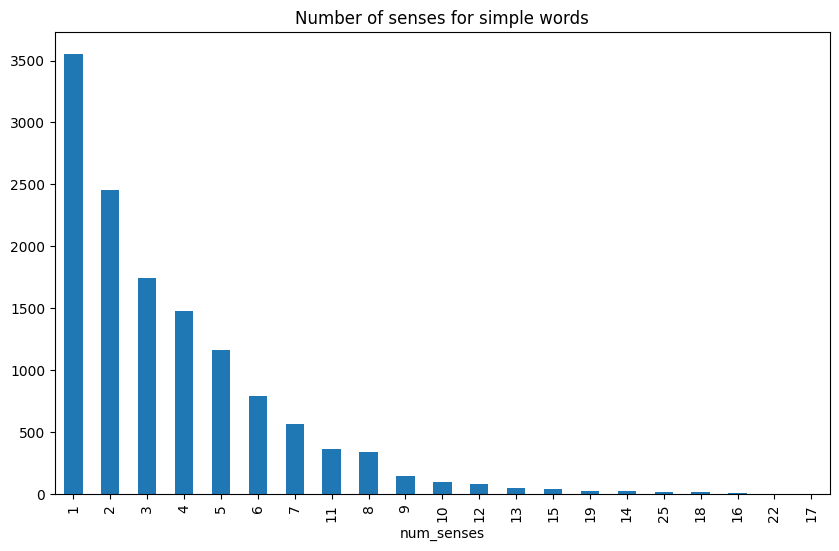

In [44]:
#make this into graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sws_df["num_senses"].value_counts().plot(kind='bar')
plt.title("Number of senses for simple words")  




In [45]:
def mark_token(token, sentence, start_mark = "<b>", end_mark = "</b>"):
    """
    Mark a token in a sentence with tags. Default tags are HTML <b> and </b>. but can be changed to any other tags. For example, to usee ** and ** for markdown, use start_mark = "**" and end_mark = "**".


    Args:
        token: AnnotationToken object representing the token to be marked.
        sentence: AnnotatedSentenceWithMWEs object representing the sentence containing the token.
        start_mark: The opening tag for marking (default is "<b>").
        end_mark: The closing tag for marking (default is "</b>").

    Returns:
        str: The marked sentence with the token highlighted.
    """
    # Get the start and end indices of the token in the sentence text
    start_index = token.start
    end_index = token.end

    # Create the marked sentence
    marked_sentence = (
        sentence.text[:start_index] +
        start_mark + token.text + end_mark +
        sentence.text[end_index:]
    )

    return marked_sentence

In [46]:
sentece = senteces[0]
for token in sentece.tokens:
    print(mark_token(token, sentece))
    print("")

<b>U</b> petoj sezoni program je održan u skladu sa novim konceptom: jedan mladi fudbaler iz svake zemlje izabran je kao njen predstavnik.

U <b>petoj</b> sezoni program je održan u skladu sa novim konceptom: jedan mladi fudbaler iz svake zemlje izabran je kao njen predstavnik.

U petoj <b>sezoni</b> program je održan u skladu sa novim konceptom: jedan mladi fudbaler iz svake zemlje izabran je kao njen predstavnik.

U petoj sezoni <b>program</b> je održan u skladu sa novim konceptom: jedan mladi fudbaler iz svake zemlje izabran je kao njen predstavnik.

U petoj sezoni program <b>je</b> održan u skladu sa novim konceptom: jedan mladi fudbaler iz svake zemlje izabran je kao njen predstavnik.

U petoj sezoni program je <b>održan</b> u skladu sa novim konceptom: jedan mladi fudbaler iz svake zemlje izabran je kao njen predstavnik.

U petoj sezoni program je održan <b>u</b> skladu sa novim konceptom: jedan mladi fudbaler iz svake zemlje izabran je kao njen predstavnik.

U petoj sezoni progr

In [47]:
from writers import 
def mark_tokens(tokens: list, sentence: AnnotatedSentenceWithMWEs, start_mark="<b>", end_mark="</b>") -> str:
    """
    Mark multiple tokens in a sentence with tags. Default tags are HTML <b> and </b>,
    but can be changed to any other markers (e.g., "**" for Markdown).

    This handles tokens that may be scattered throughout the sentence. Since inserting
    markers shifts subsequent character indices, we sort by the original start position
    and maintain an offset to correctly place each pair of markers.

    Args:
        tokens (list): AnnotationToken objects to be highlighted.
        sentence (AnnotatedSentenceWithMWEs): The sentence containing the tokens.
        start_mark (str): Opening tag/marker. Default: "<b>".
        end_mark (str): Closing tag/marker. Default: "</b>".

    Returns:
        str: The sentence text with all specified tokens wrapped in the given markers.
    """
    # Work on a copy of the sentence text
    text = sentence.text
    # Sort tokens by their original start position
    sorted_tokens = sorted(tokens, key=lambda t: t.start)
    # Track how much we've shifted the indices by inserting markers
    offset = 0

    for token in sorted_tokens:
        orig_start, orig_end = token.start, token.end
        # Adjust for previously inserted markers
        start = orig_start + offset
        end = orig_end + offset

        # Insert the markers around the token's text
        text = (
            text[:start]
            + start_mark
            + text[start:end]
            + end_mark
            + text[end:]
        )

        # Update offset: we've added these many characters
        offset += len(start_mark) + len(end_mark)

    return text



SyntaxError: invalid syntax (62012606.py, line 1)

In [ ]:
sentece = senteces[0]

for mwe in sentece.mwes:
    tokens = []
    token_indices = mwe.token_indices
    for token_index in token_indices:
        tokens.append(sentece.tokens[token_index])
    print(mark_tokens(tokens, sentece)) 
    print("")

In [ ]:
from typing import List

def get_mwe_tokens(sentence: AnnotatedSentenceWithMWEs, mwe) -> List[AnnotationToken]:
    """
    Retrieve the list of tokens that make up a given multi-word expression (MWE)
    within a sentence.

    Args:
        sentence (AnnotatedSentenceWithMWEs): The sentence containing the MWE.
        mwe: An object with a `.token_indices` attribute listing token positions.

    Returns:
        List[AnnotationToken]: The tokens from `sentence.tokens` at the indices
        specified by `mwe.token_indices`.
    """
    return [sentence.tokens[i] for i in mwe.token_indices]


In [ ]:
from typing import List

def mark_mwe(mwe, sentence, start_mark: str = "<b>", end_mark: str = "</b>") -> str:
    """
    Highlight an entire multi-word expression (MWE) within its sentence by wrapping
    it in the specified markers.

    This function:
      1. Retrieves all tokens belonging to the MWE via `get_mwe_tokens`.
      2. Delegates to `mark_tokens`, which correctly inserts markers around each
         token and adjusts for shifting indices.
      
    Args:
        mwe (MultiWordExpression):
            The MWE to highlight. Must have `.token_indices: List[int]`.
        sentence (AnnotatedSentenceWithMWEs):
            The sentence containing the MWE. Must have:
              - `.tokens: List[AnnotationToken]`
              - `.text: str`
        start_mark (str):
            The opening marker. Defaults to HTML `<b>`.
        end_mark (str):
            The closing marker. Defaults to HTML `</b>`.

    Returns:
        str: A new string where the MWE in `sentence.text` is wrapped in
             `start_mark` and `end_mark`.
    """
    # Fetch MWE tokens using the configured layer key
    tokens: List = get_mwe_tokens(sentence, mwe)
    # Wrap them in the sentence text, handling index shifts
    return mark_tokens(tokens, sentence, start_mark, end_mark)


In [ ]:
for mwe in sentece.mwes:
    print(mark_mwe(mwe, sentece)) 
    print("")

In [ ]:
from config import OPENAI_API_KEY, GOOGLE_GENAI_API_KEY

print(OPENAI_API_KEY)
print(GOOGLE_GENAI_API_KEY)
print("API keys are set correctly.")

In [ ]:
sent.entities

In [ ]:
def get_ne_tokens(sentence: AnnotatedSentenceWithMWEs, ne) -> List[AnnotationToken]:
    """
    Retrieve the list of tokens that make up a given named entity (NE) within a sentence.

    Args:
        sentence (AnnotatedSentenceWithMWEs): The sentence containing the NE.
        ne: touple with the NE information (start, end, label, id)

    Returns:
        List[AnnotationToken]: The tokens from `sentence.tokens` at the indices
        specified by `ne.token_indices`.
    """
    start, end, label, id = ne
    return [token for token in sentence.tokens if token.start >= start and token.end <= end]

In [ ]:
for ne in sent.entities:
    _, _ , label, id = ne
    print (f"Entity: {label}, ID: {id}")
    tokens = get_ne_tokens(sent, ne)
    for token in tokens:
        print(token)

In [ ]:
def get_ne_lemma(sentence: AnnotatedSentenceWithMWEs, ne) -> str:
    """
    Retrieve the lemma of a named entity (NE) within a sentence.

    Args:
        sentence (AnnotatedSentenceWithMWEs): The sentence containing the NE.
        ne: touple with the NE information (start, end, label, id)

    Returns:
        str: The lemma of the NE.
    """
    tokens = get_ne_tokens(sentence, ne)
    lemmas = [token.layers[L_LEMMA] for token in tokens]
    return " ".join(lemmas)

In [ ]:
for ne in sent.entities:
    _, _ , label, id = ne
    print (f"Entity: {label}, ID: {id}")
    tokens = get_ne_tokens(sent, ne)
    for token in tokens:
        print(token)
    lemma = get_ne_lemma(sent, ne)
    print(f"NE lemma: {lemma}")

In [ ]:
test_parser = WebAnnoLEXISParser(TEST_TSV)
test_sentences = test_parser.parse()

for sentence in test_sentences:
    for ne in sentence.entities:
        _, _ , label, id = ne
        print (f"Entity: {label}, ID: {id}")
        tokens = get_ne_tokens(sentence, ne)
        for token in tokens:
            print(token)
        lemma = get_ne_lemma(sentence, ne)
        print(f"NE lemma: {lemma}")
        print("")
        print("")

In [ ]:
def mark_ne(ne, sentence, start_mark: str = "<b>", end_mark: str = "</b>") -> str:
    """
    Highlight a named entity (NE) within its sentence by wrapping it in the specified markers.

    Since all named entities are contiguous, we can directly slice the sentence text
    using the start and end indices from the NE tuple.     
    Args:
        ne (tuple):
            The NE to highlight. Must have `(start, end, label, id)`.
        sentence (AnnotatedSentenceWithMWEs):
            The sentence containing the NE. Must have:
              - `.tokens: List[AnnotationToken]`
              - `.text: str`
        start_mark (str):
            The opening marker. Defaults to HTML `<b>`.
        end_mark (str):
            The closing marker. Defaults to HTML `</b>`.

    Returns:
        str: A new string where the NE in `sentence.text` is wrapped in
             `start_mark` and `end_mark`.
    """
    # Fetch NE tokens using the configured layer key
    start, end, _, _ = ne
    marhed_sentence = sentence.text[:start] + start_mark + sentence.text[start:end] + end_mark + sentence.text[end:]
    return marhed_sentence

In [ ]:
from config import EVENT_FILTER

def collect_event_sense (senteces: List[AnnotatedSentenceWithMWEs], sense_repo_df: pd.DataFrame) -> List[dict]:
    """
    For each event in the sentences, look up its senses in the sense repository.

    Args:
        senteces (List[AnnotatedSentenceWithMWEs]): The sentences to process.
        sense_repo_df (pd.DataFrame): The sense repository DataFrame.

    Returns:
        List[dict]: A list of dictionaries containing event senses and their counts.
    """
    event_senses = []

    for sentece in senteces:
        for ent in sentece.entities:
            _ , _ , label, _ = ent
            # Skip if the label is not in the EVENT_FILTER
            if label not in EVENT_FILTER:
                continue

            # Must have a lemma layer
            lemma = get_ne_lemma(sentece, ent)

            # Filter for exact lemma matches in the sense repository
            filtered_rows = sense_repo_df[sense_repo_df[S_LEMMA] == lemma]

            event_sense = {
                "lemma":                lemma,
                "senses":               filtered_rows,
                "num_senses":           len(filtered_rows),
                "marked_sentence":      mark_ne(ent, sentece),
                "originating_sentence": sentece.text,
            }
            event_senses.append(event_sense)
    return event_senses

In [ ]:
test_event_senses = collect_event_sense(test_sentences, sense_repo_df)

test_event_senses_df = pd.DataFrame(test_event_senses)
test_event_senses_df["num_senses"].value_counts()


In [ ]:
print(test_event_senses)

In [ ]:
event_senses= collect_event_sense(senteces, sense_repo_df)

event_senses_df = pd.DataFrame(event_senses)
event_senses_df["num_senses"].value_counts()

In [ ]:
no_sense_events = []

for event_sense in event_senses:
    if event_sense["num_senses"] == 0:
        no_sense_events.append(event_sense["lemma"])

no_sense_events = list(set(no_sense_events))

print(f"Events with no sense: {no_sense_events}")
